In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from fine_tune import ModelFineTuner
from blue_blob_images_float import image_to_float
from tensorflow.keras.applications import ResNet50V2, EfficientNetB3, ResNet101V2
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess_input 

In [2]:
galaxies_images = image_to_float("galaxy_train")*255
galaxies_val_images = image_to_float("galaxy_val")*255
blue_blob_data_array_float = image_to_float("blue_blob_train_images_new")*255
blue_blob_val_data_array_float = image_to_float("blueblobs_val")*255
devices = tf.config.list_physical_devices()
print("\nDevices: ", devices)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  details = tf.config.experimental.get_device_details(gpus[0])
  print("GPU details: ", details)

# --- 2. Data Loading and Preparation ---


print(f"Galaxy images shape: {galaxies_images.shape}, dtype: {galaxies_images.dtype}")
print(f"Blue blob images shape: {blue_blob_data_array_float.shape}, dtype: {blue_blob_data_array_float.dtype}")
print(f"Galaxy val images shape: {galaxies_val_images.shape}, dtype: {galaxies_val_images.dtype}")
print(f"Blue blob val images shape: {blue_blob_val_data_array_float.shape}, dtype: {blue_blob_val_data_array_float.dtype}")


indices = np.arange(galaxies_images.shape[0]+ blue_blob_data_array_float.shape[0])

# Shuffle the indices randomly IN-PLACE
np.random.shuffle(indices)
galaxy_train_labels = np.ones(galaxies_images.shape[0], dtype=np.int64)
blue_blob_train_labels = np.zeros(blue_blob_data_array_float.shape[0], dtype=np.int64)
X_train = np.concatenate((galaxies_images, blue_blob_data_array_float), axis=0)
y_train = np.concatenate((galaxy_train_labels, blue_blob_train_labels), axis=0)
X_train = X_train[indices]
y_train = y_train[indices]
indices = np.arange(galaxies_val_images.shape[0]+ blue_blob_val_data_array_float.shape[0])

# Shuffle the indices randomly IN-PLACE
np.random.shuffle(indices)
galaxy_val_labels = np.ones(galaxies_val_images.shape[0], dtype=np.int64)
blue_blob_val_labels = np.zeros(blue_blob_val_data_array_float.shape[0], dtype=np.int64)
X_val = np.concatenate((galaxies_val_images, blue_blob_val_data_array_float), axis=0)
y_val = np.concatenate((galaxy_val_labels, blue_blob_val_labels), axis=0)
X_val = X_val[indices]
y_val = y_val[indices]

print("Finished splitting.")
print(f"Training images shape:   {X_train.shape}") # e.g., (6493, 256, 256, 3)
print(f"Training labels shape:   {y_train.shape}") # e.g., (6493,)
print(f"Validation images shape: {X_val.shape}")   # e.g., (1623, 256, 256, 3)
print(f"Validation labels shape: {y_val.shape}")   # e.g., (1623,)


Attempting to load JPEG images from: galaxy_train using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 680 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 680 images.
Final NumPy array shape: (680, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: galaxy_val using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 306 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 306 images.
Final NumPy array shape: (306, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: blue_blob_train_images_new using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 600 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 600 image

In [3]:
def preprocess_data_resnet(X):
    """trains a convolutional neural network to classify the dataset"""
    X_p = resnet_preprocess_input(X)
    return X_p



In [4]:
X_copy = np.copy(X_train)
X_val_copy = np.copy(X_val)
X_train_resnet = preprocess_data_resnet(X_copy)
X_val_resnet = preprocess_data_resnet(X_val_copy)
print(f"Preprocessed training images shape:   {X_train.shape}") # e.g., (6493, 256, 256, 3)
print(f"Preprocessed training labels shape:   {y_train.shape}") # e.g., (6493,)
print(f"Preprocessed validation images shape: {X_val.shape}")   # e.g., (1623, 256, 256, 3)
print(f"Preprocessed validation labels shape: {y_val.shape}")   # e.g., (1623,)


Preprocessed training images shape:   (1280, 256, 256, 3)
Preprocessed training labels shape:   (1280,)
Preprocessed validation images shape: (547, 256, 256, 3)
Preprocessed validation labels shape: (547,)


In [19]:
X_copy = np.copy(X_train)
X_val_copy = np.copy(X_val)
X_train_efficientnet = X_copy
X_val_efficientnet = X_val_copy
print(f"Preprocessed training images shape:   {X_train.shape}") # e.g., (6493, 256, 256, 3)
print(f"Preprocessed training labels shape:   {y_train.shape}") # e.g., (6493,) 

Preprocessed training images shape:   (1280, 256, 256, 3)
Preprocessed training labels shape:   (1280,)


In [5]:
model = keras.models.load_model('resnet_50V2_mlp/epoch_20.keras')
base_model = ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3),
    pooling="avg" 
)

2025-05-06 00:18:28.296383: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-05-06 00:18:28.296549: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-05-06 00:18:28.296554: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-05-06 00:18:28.296594: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-06 00:18:28.296611: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Class weights for training dataset: {0: 1.0666666666666667, 1: 0.9411764705882353}
Trainable backbone layers: ['conv5_block3_preact_bn', 'conv5_block3_preact_relu', 'conv5_block3_1_conv', 'conv5_block3_1_bn', 'conv5_block3_1_relu', 'conv5_block3_2_pad', 'conv5_block3_2_conv', 'conv5_block3_2_bn', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_out', 'post_bn', 'post_relu', 'avg_pool']

--- Starting Fine-tuning ---
Epoch 1/20


2025-05-06 00:18:35.299708: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.9620 - loss: 0.1743 - precision_gal: 0.9821 - recall_gal: 0.9448
Epoch 1: val_loss improved from inf to 0.19490, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 415ms/step - accuracy: 0.9622 - loss: 0.1741 - precision_gal: 0.9821 - recall_gal: 0.9451 - val_accuracy: 0.9525 - val_loss: 0.1949 - val_precision_gal: 0.9242 - val_recall_gal: 0.9967 - learning_rate: 5.0000e-06
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9736 - loss: 0.1739 - precision_gal: 0.9876 - recall_gal: 0.9610
Epoch 2: val_loss did not improve from 0.19490
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 344ms/step - accuracy: 0.9738 - loss: 0.1736 - precision_gal: 0.9876 - recall_gal: 0.9613 - val_accuracy: 0.9506 - val_loss: 0.1953 - val_precision_gal: 0.9215 - val_recall_gal: 0.9967 - learning_rate: 5.0000e-06
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9854 - loss: 0.1521 - precision_gal: 0.9978 - recall_gal: 0.9745
Ep

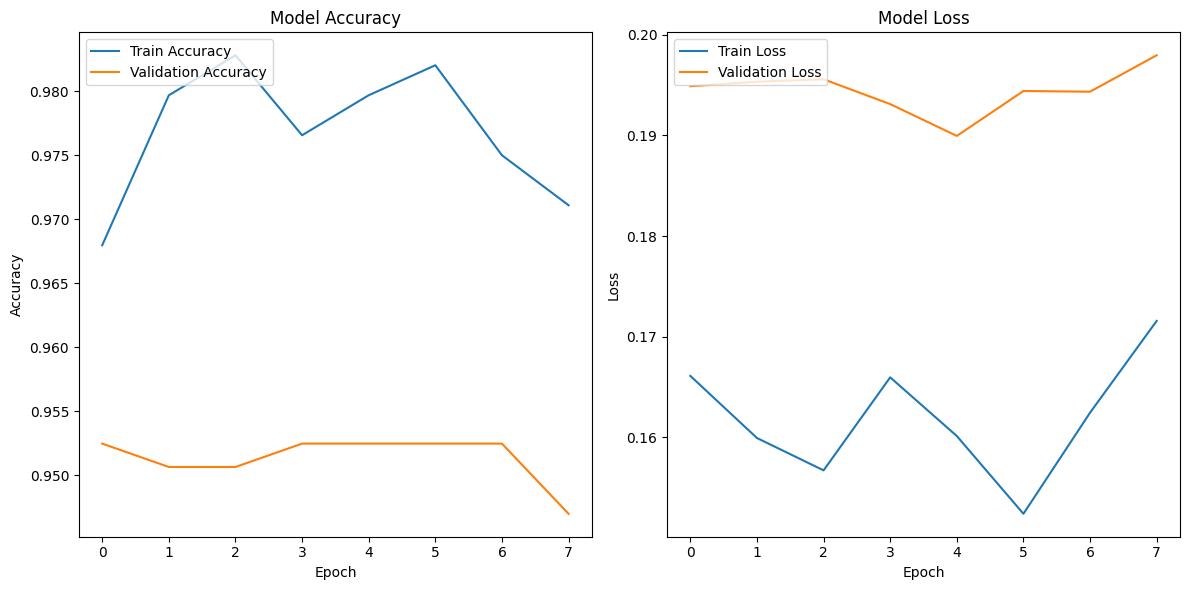

In [6]:
tuner = ModelFineTuner(model, base_model)
tuner.fine_tune(
    X_train_resnet, y_train,
    X_val_resnet,   y_val,
    num_unfreeze_layers=14,
    learning_rate=5e-6,
    epochs=20,
    early_stop="val_loss",
    es_patience=3,
    rlr_patience=3
)


In [ ]:
tuner.save_model("final_models/blue_blob_galaxy_resnet_50V2_mlp_fine_tuned.keras")

Model saved to final_models/blue_blob_galaxy_resnet_50V2_mlp_fine_tuned.keras


: 

## Simpler Model

In [5]:
model_simpler = keras.models.load_model('final_models/blue_blob_galaxy_ResNet50V2_nohead.keras')
base_model = ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3),
)

2025-05-04 20:56:35.917129: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-05-04 20:56:35.918659: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-05-04 20:56:35.918665: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-05-04 20:56:35.919945: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-04 20:56:35.919982: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Class weights for training dataset: {0: 1.0666666666666667, 1: 0.9411764705882353}
Trainable backbone layers: ['conv5_block2_out', 'conv5_block3_preact_bn', 'conv5_block3_preact_relu', 'conv5_block3_1_conv', 'conv5_block3_1_bn', 'conv5_block3_1_relu', 'conv5_block3_2_pad', 'conv5_block3_2_conv', 'conv5_block3_2_bn', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_out', 'post_bn', 'post_relu']

--- Starting Fine-tuning ---
Epoch 1/20


2025-05-04 20:56:43.310565: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9411 - loss: 0.2764 - precision_gal: 0.9718 - recall_gal: 0.9155
Epoch 1: val_loss improved from inf to 0.25372, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 427ms/step - accuracy: 0.9413 - loss: 0.2763 - precision_gal: 0.9721 - recall_gal: 0.9158 - val_accuracy: 0.9506 - val_loss: 0.2537 - val_precision_gal: 0.9240 - val_recall_gal: 0.9935 - learning_rate: 5.0000e-06
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.9438 - loss: 0.2802 - precision_gal: 0.9720 - recall_gal: 0.9162
Epoch 2: val_loss improved from 0.25372 to 0.25294, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 352ms/step - accuracy: 0.9440 - loss: 0.2800 - precision_gal: 0.9722 - recall_gal: 0.9166 - val_accuracy: 0.9506 - val_loss: 0.2529 - val_precision_gal: 0.9240 - val_recall_gal: 0.9935 - learning_rate: 5.0000e-06
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9531 - loss: 0.2731 - precisi

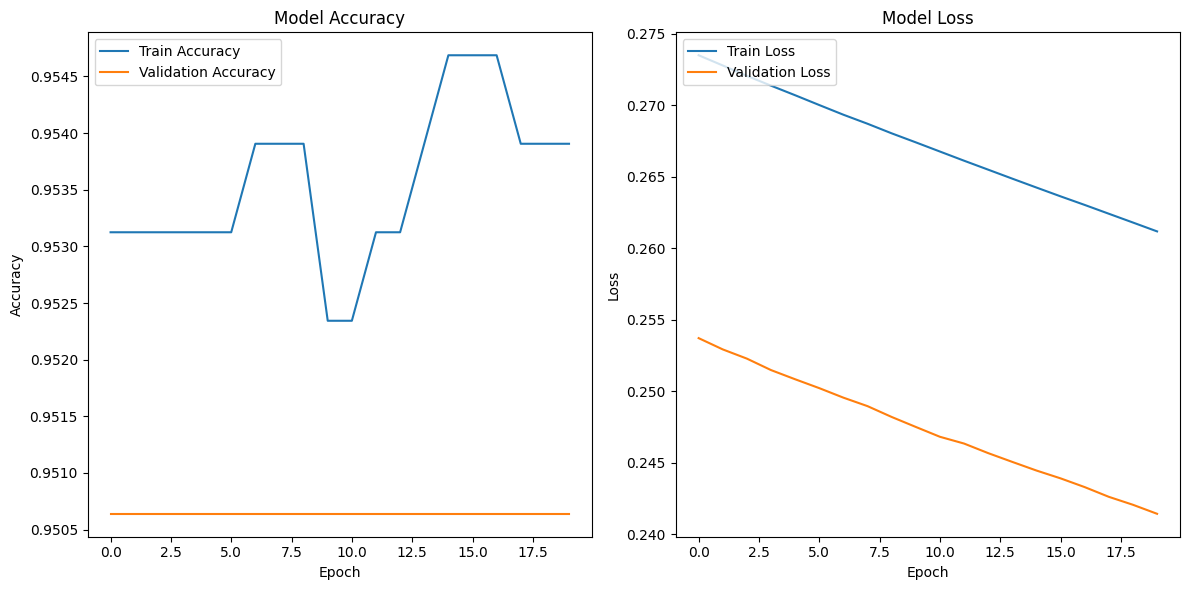

In [6]:
tuner_simpler = ModelFineTuner(model_simpler, base_model)
tuner_simpler.fine_tune(
    X_train_resnet, y_train,
    X_val_resnet,   y_val,
    num_unfreeze_layers=14,
    learning_rate=5e-6,
    epochs=20,
    early_stop="val_loss",
    es_patience=3,
    rlr_patience=3
)

In [7]:
tuner_simpler.save_model("final_models/blue_blob_galaxy_ResNet50V2_nohead_fine_tune.keras")

Model saved to final_models/blue_blob_galaxy_ResNet50V2_nohead_fine_tune.keras


## efficientNet


In [22]:
model_effecient = keras.models.load_model('final_models/blue_blob_galaxy_efficientB3_mlp.keras')
base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3),
)

Class weights for training dataset: {0: 1.0666666666666667, 1: 0.9411764705882353}
Trainable backbone layers: ['top_conv', 'top_bn', 'top_activation']

--- Starting Fine-tuning ---
Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9858 - loss: 0.0484 - precision_gal: 0.9949 - recall_gal: 0.9774
Epoch 1: val_loss improved from inf to 0.20419, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 43s 868ms/step - accuracy: 0.9859 - loss: 0.0484 - precision_gal: 0.9948 - recall_gal: 0.9776 - val_accuracy: 0.9177 - val_loss: 0.2042 - val_precision_gal: 0.8739 - val_recall_gal: 0.9967 - learning_rate: 1.0000e-06
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9894 - loss: 0.0437 - precision_gal: 0.9918 - recall_gal: 0.9886
Epoch 2: val_loss did not improve from 0.20419
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 575ms/step - accuracy: 0.9893 - loss: 0.0439 - precision_gal: 0.9918 - recall_gal: 0.9885 - val_accuracy: 0.9177 - val_loss: 0.2083 - val_precision_gal: 0

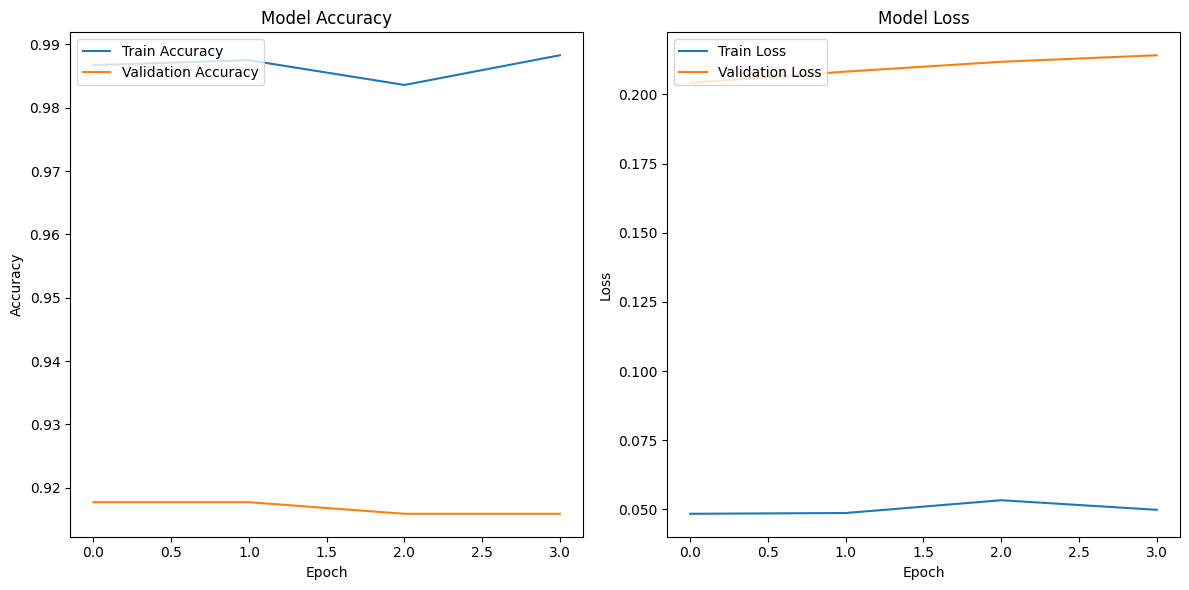

In [23]:
tuner_effecient = ModelFineTuner(model_effecient, base_model)
tuner_effecient.fine_tune(
    X_train, y_train,
    X_val,   y_val,
    num_unfreeze_layers=3,
    learning_rate=1e-6,
    epochs=25,
    early_stop="val_loss",
    es_patience=3,
    rlr_patience=3
)

In [ ]:
tuner_effecient.save_model("final_models/blue_blob_galaxy_efficientB3_mlp_fine_tune.keras")

Model saved to final_models/blue_blob_galaxy_efficientB3_mlp_fine_tune.keras


: 

In [5]:
model_simpler = keras.models.load_model("final_models/blue_blob_galaxy_resnet_101V2.keras")
base_model = ResNet101V2(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3),
)


2025-05-05 23:45:53.953720: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-05-05 23:45:53.953830: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-05-05 23:45:53.953834: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-05-05 23:45:53.953857: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-05 23:45:53.953869: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Class weights for training dataset: {0: 1.0666666666666667, 1: 0.9411764705882353}
Trainable backbone layers: ['conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_out', 'post_bn', 'post_relu']

--- Starting Fine-tuning ---
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9727 - loss: 0.3576 - precision_gal: 0.9954 - recall_gal: 0.9527
Epoch 1: val_loss improved from inf to 0.37250, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 726ms/step - accuracy: 0.9727 - loss: 0.3577 - precision_gal: 0.9953 - recall_gal: 0.9527 - val_accuracy: 0.9671 - val_loss: 0.3725 - val_precision_gal: 0.9444 - val_recall_gal: 1.0000 - learning_rate: 1.0000e-06
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.9752 - loss: 0.3754 - precision_gal: 0.9906 - recall_gal: 0.9633
Epoch 2: val_loss did not improve from 0.37250
40/40 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9753 - loss: 0.3752 - precision_gal: 0.9906 - recall_gal: 0.9633 - val_accuracy: 0

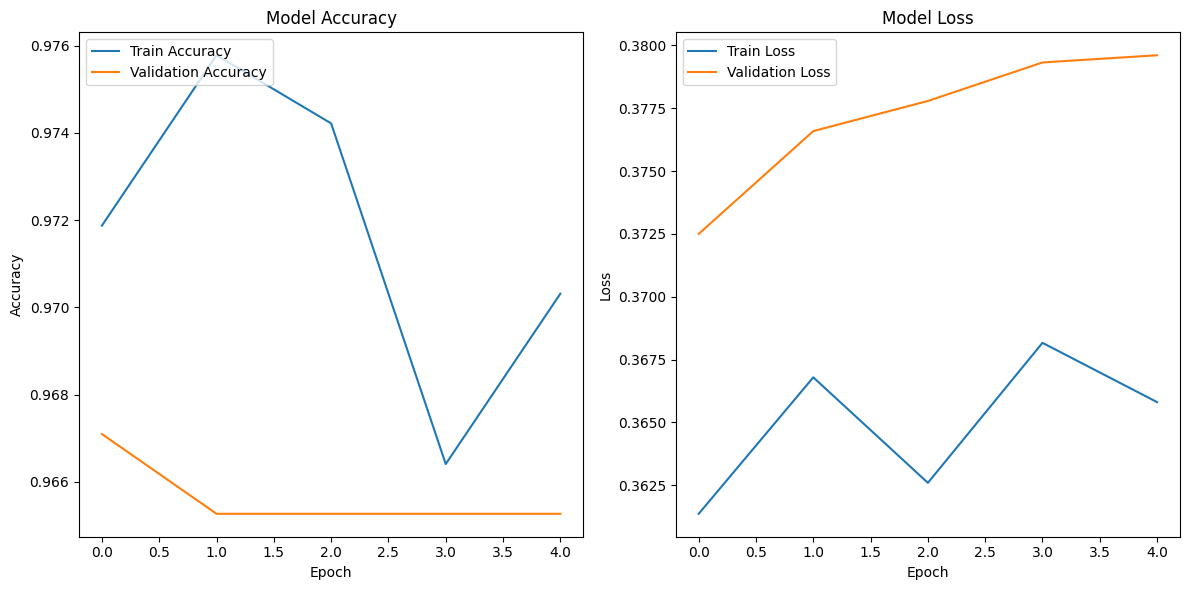

In [7]:
tuner_simpler = ModelFineTuner(model_simpler, base_model)
tuner_simpler.fine_tune(
    X_train_resnet, y_train,
    X_val_resnet,   y_val,
    num_unfreeze_layers=19,
    learning_rate=1e-6,
    epochs=20,
    early_stop="val_loss",
    es_patience=4,
    rlr_patience=4
)

In [ ]:
tuner_simpler.save_model("final_models/blue_blob_galaxy_ResNet101V2_fine_tune.keras")

Model saved to final_models/blue_blob_galaxy_ResNet101V2_fine_tune.keras


: 